# Урок 1.4. Переобучение, смещение и разброс, валидация

**Интерактивная версия:** `lessons/lesson_1_4/web/index.html`

1. Кривые ошибки на обучении и тесте.
2. Разложение ошибки на смещение², разброс и шум — экспериментально.
3. Тот же эффект у бустинга: число деревьев как «ручка сложности».
4. Валидация: hold-out и k-fold.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, RegressionTree, GBRegressor
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Обучение против теста

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


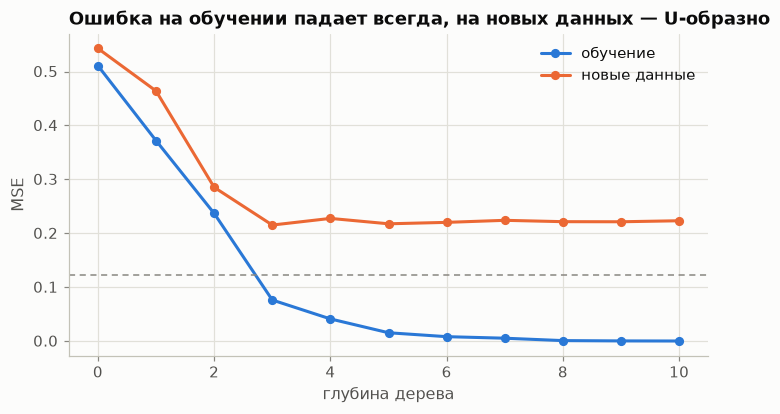

In [2]:
X, y = datasets.regression_1d(kind="sine", n=60, noise=0.35, seed=1)
X_te, y_te = datasets.regression_1d(kind="sine", n=2000, noise=0.35, seed=999)
depths = range(0, 11)
tr = [mse(y, RegressionTree(max_depth=d).fit(X, -y).predict(X)) for d in depths]
te = [mse(y_te, RegressionTree(max_depth=d).fit(X, -y).predict(X_te)) for d in depths]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(depths, tr, marker="o", label="обучение")
ax.plot(depths, te, marker="o", label="новые данные")
ax.axhline(0.35**2, color="#898781", lw=1, ls=(0, (4, 3)))
ax.set(xlabel="глубина дерева", ylabel="MSE", title="Ошибка на обучении падает всегда, на новых данных — U-образно")
ax.legend()
plt.show()

## 2. Разложение ошибки экспериментально

Обучим модель на 30 независимых выборках и посчитаем:
смещение² $= \overline{(\mathbb{E}\hat F - f)^2}$, разброс $= \overline{\mathrm{Var}\,\hat F}$.

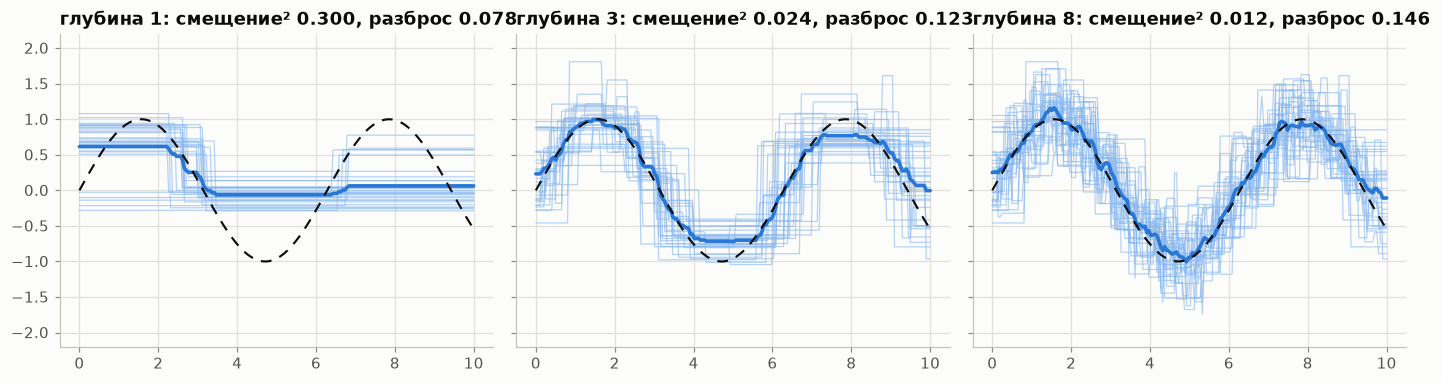

In [3]:
grid = np.linspace(0, 10, 200).reshape(-1, 1)
truth = np.sin(grid[:, 0])


def decompose(fit_predict, B=30, n=30, noise=0.35):
    """fit_predict(X, y) → прогноз на grid; обучаем на B независимых выборках."""
    preds = []
    for seed in range(1, B + 1):
        Xb, yb = datasets.regression_1d(kind="sine", n=n, noise=noise, seed=seed)
        preds.append(fit_predict(Xb, yb))
    preds = np.array(preds)
    return np.mean((preds.mean(0) - truth) ** 2), np.mean(preds.var(0)), preds


def tree_fp(depth):
    return lambda X, y: RegressionTree(max_depth=depth).fit(X, -y).predict(grid)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, depth in zip(axes, (1, 3, 8)):
    b2, var, preds = decompose(tree_fp(depth))
    for p in preds:
        ax.plot(grid, p, color="#86b6ef", lw=0.8, alpha=0.6)
    ax.plot(grid, preds.mean(0), color="#2a78d6", lw=2.4)
    ax.plot(grid, truth, color="#0b0b0b", ls=(0, (5, 4)), lw=1.4)
    ax.set_title(f"глубина {depth}: смещение² {b2:.3f}, разброс {var:.3f}")
    ax.set_ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()

## 3. Число деревьев в бустинге — та же «ручка сложности»

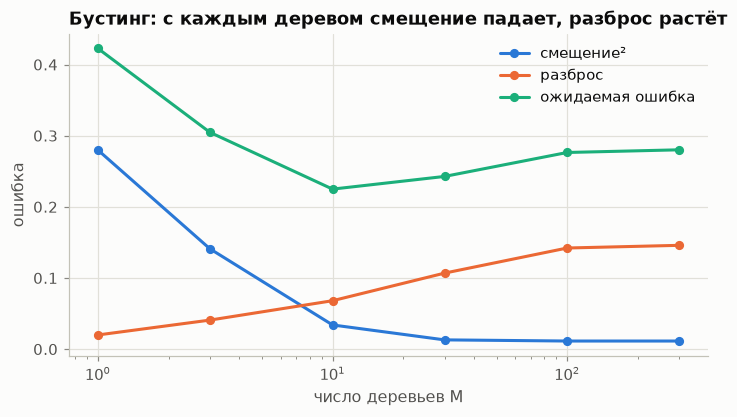

In [4]:
Ms = [1, 3, 10, 30, 100, 300]
res = [decompose(lambda X, y, m=m: GBRegressor(n_estimators=m, learning_rate=0.3, max_depth=2).fit(X, y).predict(grid))[:2]
       for m in Ms]
b2s, vars_ = zip(*res)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(Ms, b2s, marker="o", label="смещение²")
ax.plot(Ms, vars_, marker="o", label="разброс")
ax.plot(Ms, np.array(b2s) + np.array(vars_) + 0.35**2, marker="o", label="ожидаемая ошибка")
ax.set_xscale("log")
ax.set(xlabel="число деревьев M", ylabel="ошибка", title="Бустинг: с каждым деревом смещение падает, разброс растёт")
ax.legend()
plt.show()

## 4. Валидация: k-fold своими руками

In [5]:
X, y = datasets.regression_1d(kind="sine", n=150, noise=0.35, seed=1)
perm = np.random.default_rng(0).permutation(len(y))
folds = np.array_split(perm, 5)
for depth in (1, 3, 5, 8):
    errs = []
    for j in range(5):
        val = folds[j]
        trn = np.concatenate([folds[i] for i in range(5) if i != j])
        t = RegressionTree(max_depth=depth).fit(X[trn], -y[trn])
        errs.append(mse(y[val], t.predict(X[val])))
    print(f"глубина {depth}: CV MSE = {np.mean(errs):.3f} ± {np.std(errs):.3f}")

глубина 1: CV MSE = 0.470 ± 0.085
глубина 3: CV MSE = 0.217 ± 0.067
глубина 5: CV MSE = 0.199 ± 0.043
глубина 8: CV MSE = 0.232 ± 0.048


## Упражнения

1. Увеличьте n с 30 до 120 в эксперименте п. 2. Как меняются смещение и разброс для глубины 8? Почему?
2. Для бустинга с learning_rate = 0.05 найдите M, при котором ожидаемая ошибка минимальна. Сравните с learning_rate = 0.3.
3. Реализуйте «повторённую» кросс-валидацию (5 фолдов × 3 разных перемешивания) и сравните стандартное отклонение оценки с обычной.

Решения: `python lessons/lesson_1_4/exercises/solutions.py`.